In [13]:
#unhashtag this to install required libraries
%pip install pandas numpy matplotlib scikit-learn seaborn

import sys
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import ops
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam    
from tensorflow.keras.metrics import Precision
from sklearn.preprocessing import StandardScaler
print(tf.__version__)



Note: you may need to restart the kernel to use updated packages.
2.16.2


In [ ]:
#importing datasets
#at minimum include “Age”, “BMI”, and “Blood Glucose Level”

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

target = "HbA1c_level"

#Making y DataFrame for the model
y_train = train[target].astype("float32").values
y_test  = test[target].astype("float32").values


#Dropping columns that we don't need when making the x_train and x_test DataFrame
#train = train.drop(columns=["Unnamed: 0","former", "current", "ever", "never","no info", "not current", target, "male", "female", "other"])
#test = test.drop(columns=["Unnamed: 0","former", "current", "ever", "never", "no info", "not current", target, "male", "female", "other"])

#Base scenario: Removing target and ID column
train = train.drop(columns=["Unnamed: 0", target])
test = test.drop(columns=["Unnamed: 0", target])


#Scaling continuous variables for easier use in model
#Binary columns are already created via preprocessing.
def separate_cols(x):
    bin_col = pd.DataFrame()
    cont_col = pd.DataFrame()
    for col in x.columns:
        if x[col].nunique() == 2:
            bin_col[col] = x[col].values
        else:
            cont_col[col] = x[col].values
    return bin_col, cont_col

train_bin, train_cont = separate_cols(train)
test_bin, test_cont = separate_cols(test)


from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

#Scaling
scaled_tr = sc.fit_transform(train_cont)
scaled_te = sc.transform(test_cont)

#making dataframes for scaled sets
scaled_tr_cont = pd.DataFrame(scaled_tr, columns = train_cont.columns)
scaled_te_cont = pd.DataFrame(scaled_te, columns = test_cont.columns)

#Creating the independent variable datasets 
x_train = pd.concat([train_bin, scaled_tr_cont], axis = 1)
x_test = pd.concat([test_bin, scaled_te_cont], axis = 1)


#Checking dataframe to have all of the colu
#print(x_train)
#print(y_train)
#print(x_train.shape[1])

9.0


In [ ]:
### Creating Sequential Model ###

model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(x_train.shape[1],)),
        tf.keras.layers.Dense(14, activation="relu"),
        tf.keras.layers.Dense(7, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compiling

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

ann = model.fit(x_train,y_train,batch_size=128, epochs=100, validation_split=0.2, callbacks=[callback])

###uncomment this when wanting to train another model
#ann2 = model.fit(x_train,y_train,batch_size=64, epochs=100, validation_split=0.2, callbacks=[callback])



Epoch 1/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 26.7853 - mae: 5.0331 - val_loss: 21.6970 - val_mae: 4.4899
Epoch 2/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 16.6641 - mae: 3.8522 - val_loss: 11.8184 - val_mae: 3.1661
Epoch 3/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.1719 - mae: 2.5309 - val_loss: 5.1986 - val_mae: 1.9520
Epoch 4/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.5415 - mae: 1.5706 - val_loss: 2.3797 - val_mae: 1.2743
Epoch 5/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.8672 - mae: 1.1276 - val_loss: 1.5376 - val_mae: 1.0295
Epoch 6/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3830 - mae: 0.9773 - val_loss: 1.2918 - val_mae: 0.9491
Epoch 7/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2180 - mae: 0.9232 - val_loss: 1.1847 - val_mae: 0.9141
Epoch 8/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1330 - mae: 0.8966 - val_loss: 1.1199 - val_mae: 0.8953
Epoch 9/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 

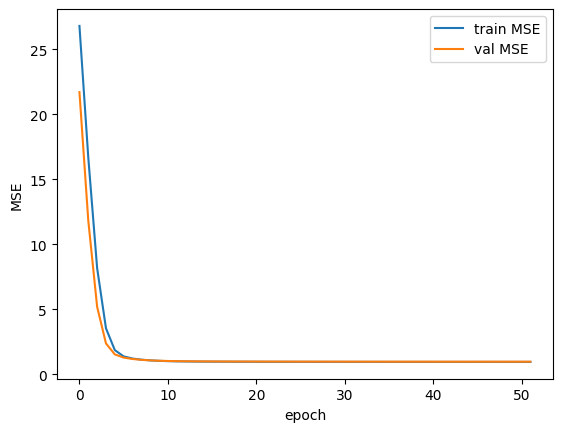

In [ ]:
import matplotlib.pyplot as plt
#y_ticks = np.arange(0, max(ann.history["loss"]), 0.5)
#plt.plot(ann.history["loss"])
#plt.yticks(y_ticks)
#plt.show()

#prints both loss and val_loss. change ann.history accordingly e.g ann2.history
#NOTE: If lines are close together, it means model is generalizing well since curve isn't deviating from the trained model.
plt.plot(ann.history['loss'], label='train MSE')
plt.plot(ann.history['val_loss'], label='val MSE')
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE'); plt.show()
#print(max(ann.history["loss"]))




In [ ]:
#Testing the data
#loss, accuracy = model.evaluate(x_test,y_test,verbose=1)
y_pred = model.predict(x_test,verbose=0).squeeze()

y_pred_df = pd.DataFrame({"y prediction": y_pred})
y_test_df = pd.DataFrame({"y test dataset": y_test})
predictions = pd.concat([y_pred_df, y_test_df], axis=1)
print(predictions)
#print(y_test)




       y prediction  y test dataset
0          5.386957             6.6
1          5.352644             4.8
2          5.355755             5.0
3          5.407691             6.1
4          5.401264             6.1
...             ...             ...
19218      5.390118             4.0
19219      6.907605             6.2
19220      5.433506             5.8
19221      5.421073             6.0
19222      5.330778             6.5

[19223 rows x 2 columns]


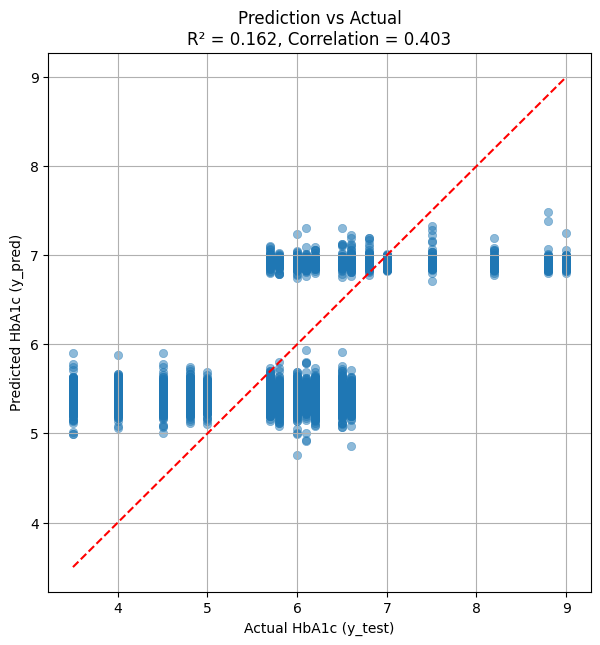

In [ ]:
import seaborn as sns
from sklearn.metrics import r2_score
# Compute correlation (R² and Pearson's r) to test the correlation between the Actual hba1c and Predicted hba1c
r2 = r2_score(y_test, y_pred)
corr = np.corrcoef(y_test, y_pred)[0,1]

# Plot correlation scatter
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line

plt.xlabel("Actual HbA1c (y_test)")
plt.ylabel("Predicted HbA1c (y_pred)")
plt.title(f"Prediction vs Actual\nR² = {r2:.3f}, Correlation = {corr:.3f}")
plt.grid(True)
plt.show()

In [ ]:
#print(x_test)
#print(y_test_df)

In [ ]:
#Writing predictions into csv

#predictions.to_csv("prediction_continuous.csv", index=False)

#pd.DataFrame(ann.history).to_csv("training_hba1c.csv", index=False)

In [ ]:
#from sklearn.linear_model import LinearRegression
#reg = LinearRegression().fit(x_train, y_train)
#print("Baseline R^2 (train):", reg.score(x_train, y_train))
#print("Baseline R^2 (test):", reg.score(x_test, y_test))
